In [1]:
### ML project: Stock market prediction using LSTM(long short term memory) ####


In [2]:
### We need to set up yfinance first ###
!pip install yfinance

In [3]:
### Installing libraries ###
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.style.use("fivethirtyeight")
import yfinance as yf  ### the library is used to download data from the yahoo finance ###
from datetime import datetime




In [4]:
#### Now deciding which companies' stock data to be downloaded and the time period ###
tech_list=["AAPL", "GOOG", "MSFT", "AMZN"]
company_name=["APPLE", "GOOGLE", "MICROSOFT", "AMAZON"]
company_list = ["AAP", "GOOG", "MSFT", "AMZN"]
end=datetime.now()
start=datetime(end.year-1, end.month, end.day)

#### Downloading Data###
data={}
for stock in tech_list:
    data[stock]=yf.download(stock,start,end)
    data[stock].columns=data[stock].columns.get_level_values(0)
#### Tagging each table with its company name ###

for stock, com_name in zip(tech_list, company_name):
    data[stock]["company_name"]=com_name

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [5]:
## combing all 4 tables(4 companies data) into one master table ###
df=pd.concat(data.values(), axis=0)

In [6]:
df.head(5)

Price,Close,High,Low,Open,Volume,company_name
Date,,,,,,
2025-09-25,255.924606,256.223520,250.783609,252.278088,55202100,APPLE
2025-09-26,254.519806,256.651929,252.845981,253.164811,46076300,APPLE
2025-09-29,253.493607,254.061516,252.078834,253.623133,40127700,APPLE
2025-09-30,253.692856,254.978101,252.178446,253.922005,37704300,APPLE
2025-10-01,254.509842,257.837561,253.991751,254.101347,48713900,APPLE


In [7]:
df

Price,Close,High,Low,Open,Volume,company_name
Date,,,,,,
2025-09-25,255.924606,256.223520,250.783609,252.278088,55202100,APPLE
2025-09-26,254.519806,256.651929,252.845981,253.164811,46076300,APPLE
2025-09-29,253.493607,254.061516,252.078834,253.623133,40127700,APPLE
2025-09-30,253.692856,254.978101,252.178446,253.922005,37704300,APPLE
2025-10-01,254.509842,257.837561,253.991751,254.101347,48713900,APPLE
...,...,...,...,...,...,...
2026-09-18,253.710007,255.429993,251.880005,252.919998,52274700,AMAZON
2026-09-21,258.450012,259.489990,253.600006,256.399994,42979400,AMAZON
2026-09-22,254.979996,259.000000,253.779999,255.110001,41982600,AMAZON


In [8]:
df.tail(10)

Price,Close,High,Low,Open,Volume,company_name
Date,,,,,,
2026-09-11,256.779999,257.589996,253.139999,254.089996,26724100,AMAZON
2026-09-14,253.539993,255.949997,250.740005,253.149994,34352800,AMAZON
2026-09-15,248.419998,253.270004,247.220001,252.240005,36275400,AMAZON
2026-09-16,245.960007,249.259995,244.300003,248.100006,33488500,AMAZON
2026-09-17,251.190002,252.729996,249.240005,251.070007,30438800,AMAZON
2026-09-18,253.710007,255.429993,251.880005,252.919998,52274700,AMAZON
2026-09-21,258.450012,259.489990,253.600006,256.399994,42979400,AMAZON
2026-09-22,254.979996,259.000000,253.779999,255.110001,41982600,AMAZON
2026-09-23,249.270004,253.990005,247.759995,253.000000,44209200,AMAZON


In [9]:
df.head(50)

Price,Close,High,Low,Open,Volume,company_name
Date,,,,,,
2025-09-25,255.924606,256.223520,250.783609,252.278088,55202100,APPLE
2025-09-26,254.519806,256.651929,252.845981,253.164811,46076300,APPLE
2025-09-29,253.493607,254.061516,252.078834,253.623133,40127700,APPLE
2025-09-30,253.692856,254.978101,252.178446,253.922005,37704300,APPLE
2025-10-01,254.509842,257.837561,253.991751,254.101347,48713900,APPLE
2025-10-02,256.183685,257.229809,253.214642,255.635691,42630200,APPLE
2025-10-03,257.070404,258.285915,253.015391,253.732742,49155600,APPLE
2025-10-06,255.745270,258.116515,254.111306,257.040473,44664100,APPLE
2025-10-07,255.536072,256.452669,254.489918,255.864844,31955800,APPLE


In [10]:
data["AAPL"]

Price,Close,High,Low,Open,Volume,company_name
Date,,,,,,
2025-09-25,255.924606,256.223520,250.783609,252.278088,55202100,APPLE
2025-09-26,254.519806,256.651929,252.845981,253.164811,46076300,APPLE
2025-09-29,253.493607,254.061516,252.078834,253.623133,40127700,APPLE
2025-09-30,253.692856,254.978101,252.178446,253.922005,37704300,APPLE
2025-10-01,254.509842,257.837561,253.991751,254.101347,48713900,APPLE
...,...,...,...,...,...,...
2026-09-18,336.130005,338.489990,332.529999,337.910004,86588200,APPLE
2026-09-21,338.980011,339.640015,333.049988,335.279999,34999200,APPLE
2026-09-22,339.750000,345.339996,338.750000,340.140015,40711800,APPLE


In [11]:
data["GOOG"]

Price,Close,High,Low,Open,Volume,company_name
Date,,,,,,
2025-09-25,245.928009,246.671064,241.020806,244.202503,17379800,GOOGLE
2025-09-26,246.536407,249.468755,245.997820,247.139843,16594600,GOOGLE
2025-09-29,243.723755,250.992773,242.566772,247.628555,23157200,GOOGLE
2025-09-30,242.915863,243.040538,238.947219,242.427133,22541200,GOOGLE
2025-10-01,244.900681,246.506489,238.577192,240.552032,23967700,GOOGLE
...,...,...,...,...,...,...
2026-09-18,344.410004,355.130005,343.869995,351.220001,34108900,GOOGLE
2026-09-21,350.869995,353.299988,344.799988,346.190002,18252200,GOOGLE
2026-09-22,347.410004,359.980011,345.739990,353.239990,20165100,GOOGLE


In [12]:
data["MSFT"]

Price,Close,High,Low,Open,Volume,company_name
Date,,,,,,
2025-09-25,502.892334,505.848026,500.918583,504.151959,15786500,MICROSOFT
2025-09-26,507.286194,509.745967,502.485695,505.897625,16213100,MICROSOFT
2025-09-29,510.400513,512.632151,504.727221,507.325835,17617800,MICROSOFT
2025-09-30,513.723267,513.931514,505.500909,509.051681,19728200,MICROSOFT
2025-10-01,515.468872,516.262331,507.514301,510.598907,22632300,MICROSOFT
...,...,...,...,...,...,...
2026-09-18,493.779999,498.649994,491.100006,497.970001,39622300,MICROSOFT
2026-09-21,501.609985,501.869995,491.329987,494.950012,27959900,MICROSOFT
2026-09-22,498.000000,508.500000,493.649994,507.320007,21652800,MICROSOFT


In [13]:
data["AMZN"]

Price,Close,High,Low,Open,Volume,company_name
Date,,,,,,
2025-09-25,218.149994,220.669998,216.470001,220.059998,52226300,AMAZON
2025-09-26,219.779999,221.050003,218.020004,219.080002,41650100,AMAZON
2025-09-29,222.169998,222.600006,219.300003,220.080002,44259200,AMAZON
2025-09-30,219.570007,222.240005,217.889999,222.029999,48396400,AMAZON
2025-10-01,220.630005,222.149994,216.610001,217.360001,43933800,AMAZON
...,...,...,...,...,...,...
2026-09-18,253.710007,255.429993,251.880005,252.919998,52274700,AMAZON
2026-09-21,258.450012,259.489990,253.600006,256.399994,42979400,AMAZON
2026-09-22,254.979996,259.000000,253.779999,255.110001,41982600,AMAZON


In [14]:
data["MSFT"]

Price,Close,High,Low,Open,Volume,company_name
Date,,,,,,
2025-09-25,502.892334,505.848026,500.918583,504.151959,15786500,MICROSOFT
2025-09-26,507.286194,509.745967,502.485695,505.897625,16213100,MICROSOFT
2025-09-29,510.400513,512.632151,504.727221,507.325835,17617800,MICROSOFT
2025-09-30,513.723267,513.931514,505.500909,509.051681,19728200,MICROSOFT
2025-10-01,515.468872,516.262331,507.514301,510.598907,22632300,MICROSOFT
...,...,...,...,...,...,...
2026-09-18,493.779999,498.649994,491.100006,497.970001,39622300,MICROSOFT
2026-09-21,501.609985,501.869995,491.329987,494.950012,27959900,MICROSOFT
2026-09-22,498.000000,508.500000,493.649994,507.320007,21652800,MICROSOFT


In [15]:
data["AMZN"]

Price,Close,High,Low,Open,Volume,company_name
Date,,,,,,
2025-09-25,218.149994,220.669998,216.470001,220.059998,52226300,AMAZON
2025-09-26,219.779999,221.050003,218.020004,219.080002,41650100,AMAZON
2025-09-29,222.169998,222.600006,219.300003,220.080002,44259200,AMAZON
2025-09-30,219.570007,222.240005,217.889999,222.029999,48396400,AMAZON
2025-10-01,220.630005,222.149994,216.610001,217.360001,43933800,AMAZON
...,...,...,...,...,...,...
2026-09-18,253.710007,255.429993,251.880005,252.919998,52274700,AMAZON
2026-09-21,258.450012,259.489990,253.600006,256.399994,42979400,AMAZON
2026-09-22,254.979996,259.000000,253.779999,255.110001,41982600,AMAZON


In [16]:
### Descriptive statistics for each stock ####
for stock in tech_list:
    print(f"Descriptive Statistics for {stock}")
    print(data[stock].describe())
    print("\n")

Descriptive Statistics for AAPL
Price       Close        High         Low        Open        Volume
count  251.000000  251.000000  251.000000  251.000000  2.510000e+02
mean   282.491812  285.325292  279.422462  282.177278  4.839269e+07
std     26.295668   26.477340   25.774318   25.944778  2.138223e+07
min    244.367310  247.934135  242.759224  245.692416  1.791060e+07
25%    260.228561  261.947510  257.429894  259.420515  3.815000e+07
50%    273.066742  275.508349  271.216017  274.210654  4.466410e+07
75%    305.988022  310.061258  302.544652  306.104996  5.174485e+07
max    339.786926  345.339996  338.750000  341.079987  2.617755e+08


Descriptive Statistics for GOOG
Price       Close        High         Low        Open        Volume
count  251.000000  251.000000  251.000000  251.000000  2.510000e+02
mean   323.608642  327.381923  319.381846  323.258213  2.117942e+07
std     36.856722   37.342172   36.279612   36.817391  8.957006e+06
min    236.871643  243.040538  236.068731  240.402

In [17]:
### Information about the data frame for each stock independently ####
for stock in tech_list:
    print(f"Information about the DataFrame for {stock}")
    print(data[stock].info())
    print("\n")

Information about the DataFrame for AAPL
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2025-09-25 to 2026-09-24
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close         251 non-null    float64
 1   High          251 non-null    float64
 2   Low           251 non-null    float64
 3   Open          251 non-null    float64
 4   Volume        251 non-null    int64  
 5   company_name  251 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 13.7+ KB
None


Information about the DataFrame for GOOG
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2025-09-25 to 2026-09-24
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close         251 non-null    float64
 1   High          251 non-null    float64
 2   Low           251 non-null    float64
 3   Open          251 non-null    float64


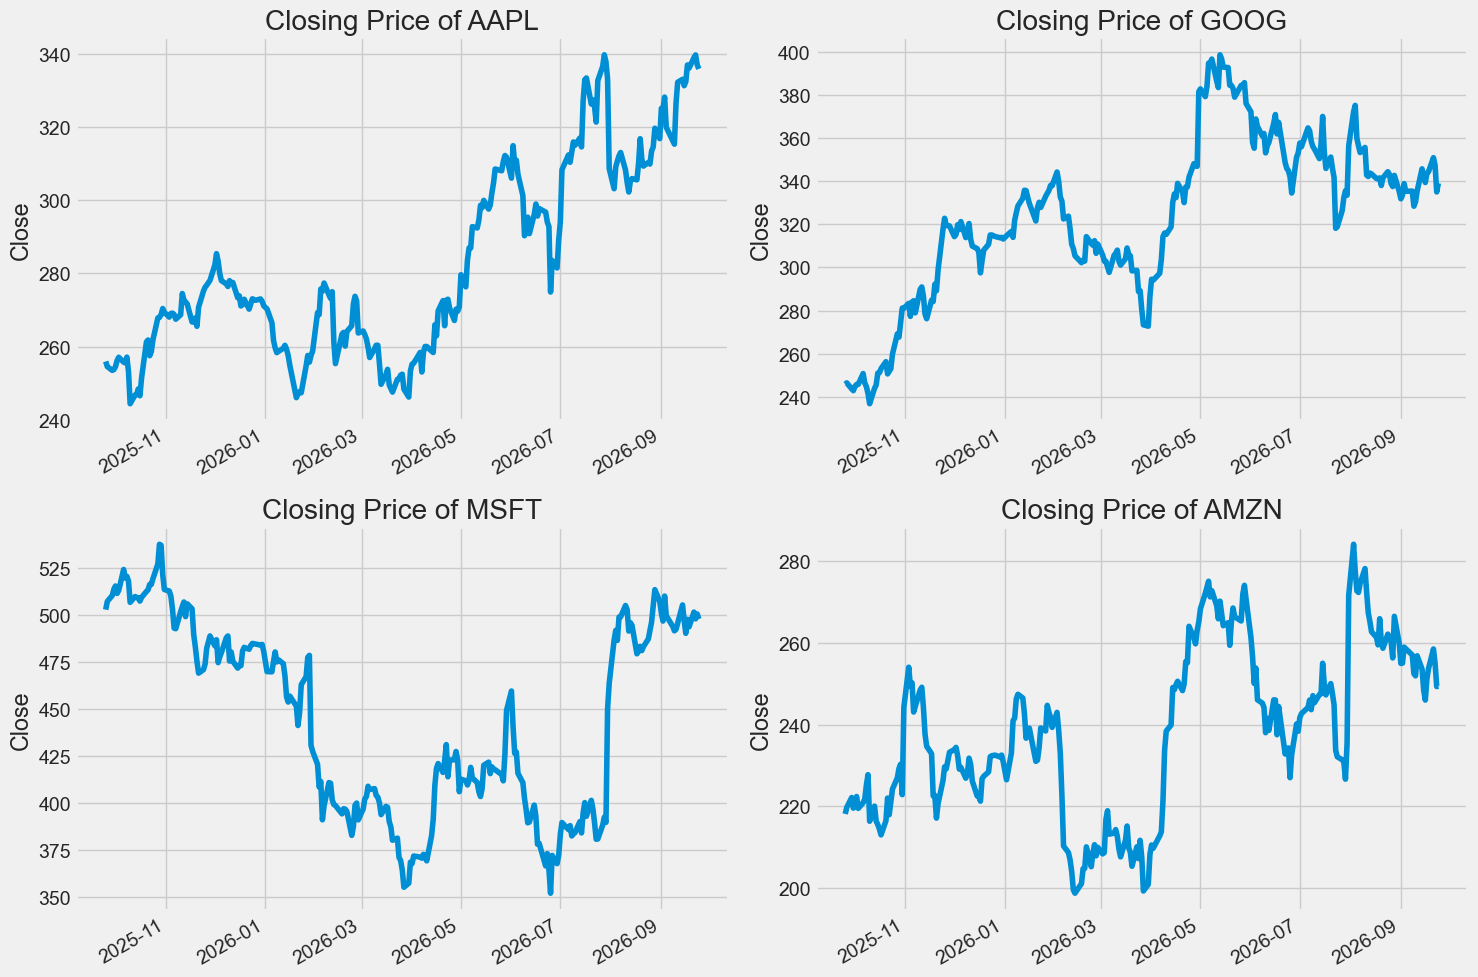

In [18]:
### Drawing charts for the four stocks separately ###
plt.figure(figsize=(15, 10))

for i, stock in enumerate(tech_list, 1):
    plt.subplot(2, 2, i)
    data[stock]['Close'].plot()
    plt.ylabel('Close')
    plt.xlabel(None)
    plt.title(f"Closing Price of {stock}")

plt.tight_layout()
plt.show()

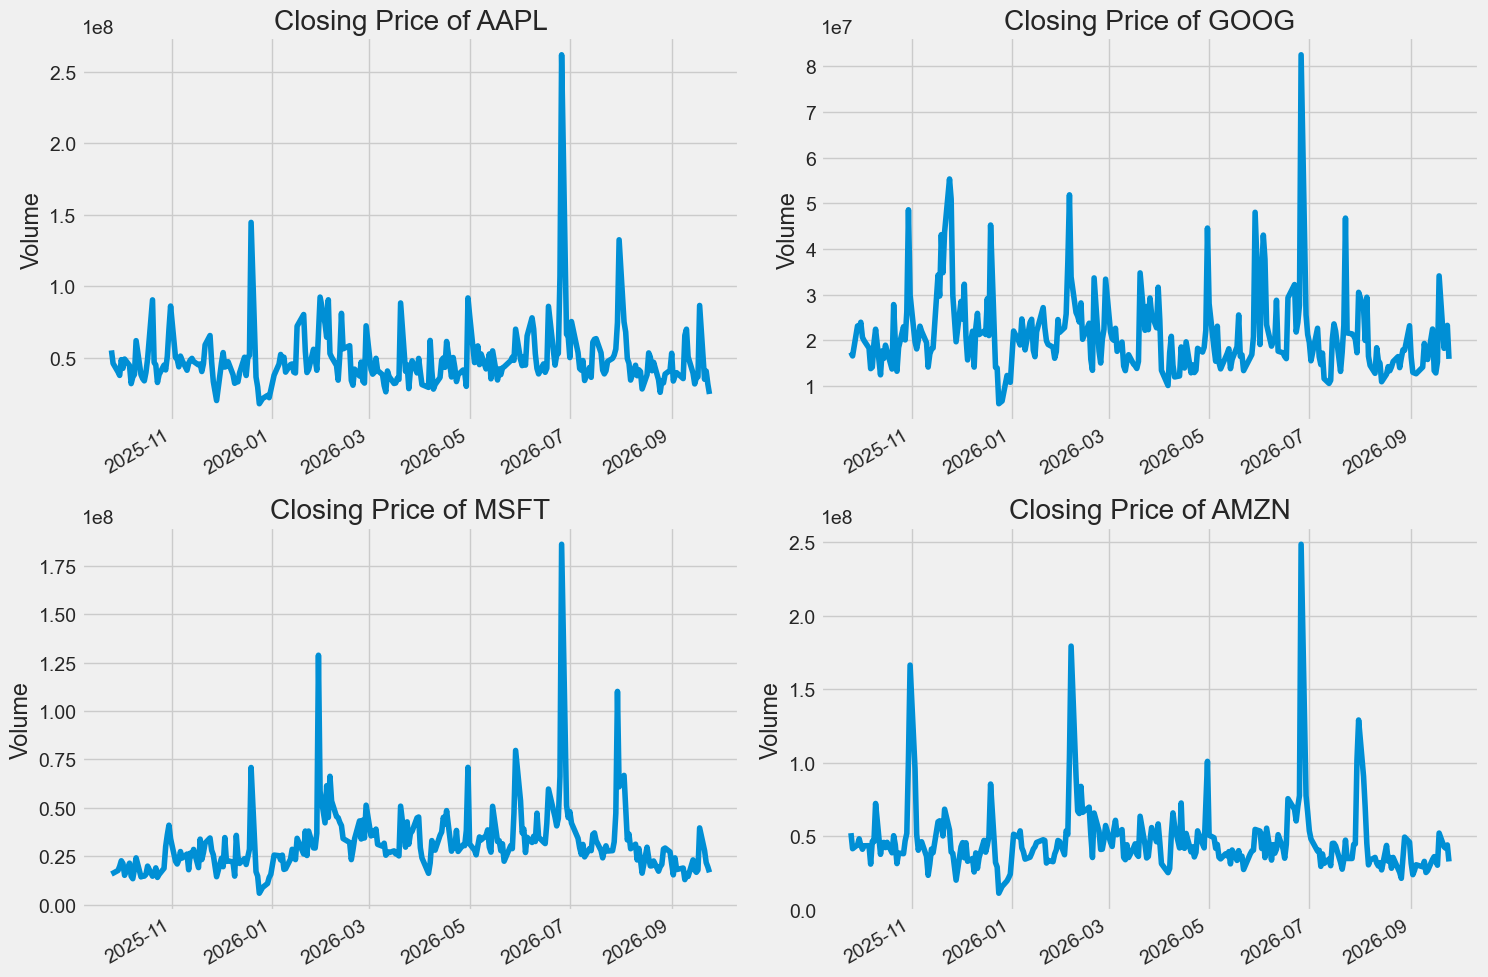

In [19]:
### Drawing charts for the four stocks separately in terms of volume ###
plt.figure(figsize=(15, 10))

for i, stock in enumerate(tech_list, 1):
    plt.subplot(2, 2, i)
    data[stock]['Volume'].plot()
    plt.ylabel('Volume')
    plt.xlabel(None)
    plt.title(f"Closing Price of {stock}")

plt.tight_layout()
plt.show()

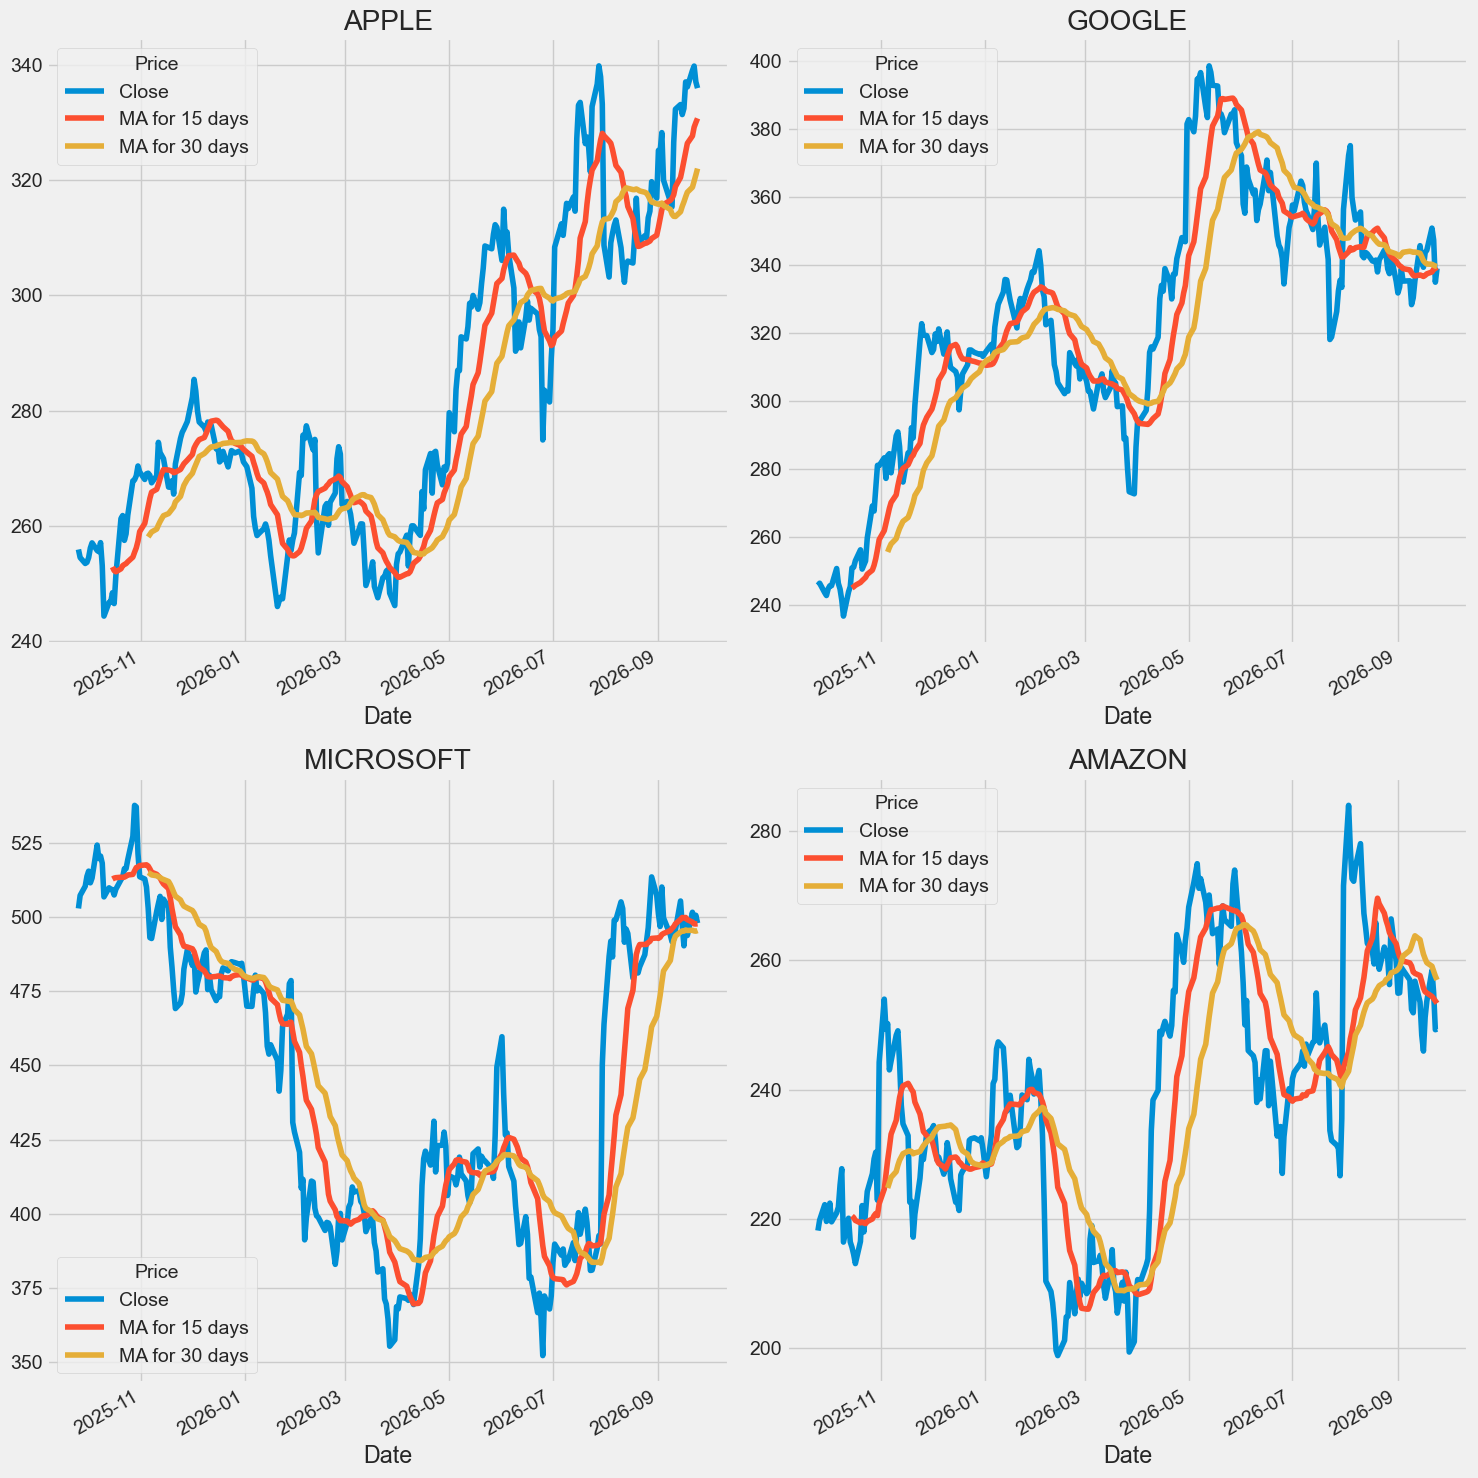

In [28]:
### Calculating moving average for the four stocks data and showing them in charts ###
ma_day=[15,30]
for ma in ma_day:
    for stock in tech_list:
        column_name=(f"MA for {ma} days")
        data[stock][column_name]=data[stock]["Close"].rolling(ma).mean()

fig,axes=plt.subplots(nrows=2,ncols=2)
fig.set_figheight(15)
fig.set_figwidth(15)
                                                        
data['AAPL'][['Close', 'MA for 15 days', 'MA for 30 days']].plot(ax=axes[0,0])
axes[0,0].set_title('APPLE')

data['GOOG'][['Close', 'MA for 15 days', 'MA for 30 days']].plot(ax=axes[0,1])
axes[0,1].set_title('GOOGLE')

data['MSFT'][['Close', 'MA for 15 days', 'MA for 30 days']].plot(ax=axes[1,0])
axes[1,0].set_title('MICROSOFT')

data['AMZN'][['Close', 'MA for 15 days', 'MA for 30 days']].plot(ax=axes[1,1])
axes[1,1].set_title('AMAZON')

plt.tight_layout()                                                                



